In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
data = pd.read_csv('features_30_sec.csv')

In [3]:
data

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,rock.00095.wav,661794,0.352063,0.080487,0.079486,0.000345,2008.149458,282174.689224,2106.541053,88609.749506,...,45.050526,-13.289984,41.754955,2.484145,36.778877,-6.713265,54.866825,-1.193787,49.950665,rock
996,rock.00096.wav,661794,0.398687,0.075086,0.076458,0.000588,2006.843354,182114.709510,2068.942009,82426.016726,...,33.851742,-10.848309,39.395096,1.881229,32.010040,-7.461491,39.196327,-2.795338,31.773624,rock
997,rock.00097.wav,661794,0.432142,0.075268,0.081651,0.000322,2077.526598,231657.968040,1927.293153,74717.124394,...,33.597008,-12.845291,36.367264,3.440978,36.001110,-12.588070,42.502201,-2.106337,29.865515,rock
998,rock.00098.wav,661794,0.362485,0.091506,0.083860,0.001211,1398.699344,240318.731073,1818.450280,109090.207161,...,46.324894,-4.416050,43.583942,1.556207,34.331261,-5.041897,47.227180,-3.590644,41.299088,rock


In [4]:
data = data.drop(columns=['filename', 'length'])

In [5]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]
le = LabelEncoder()
y = le.fit_transform(y)

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(np.array(X, dtype=float))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [7]:
X_train_exp = np.expand_dims(X_train, axis=-1)
X_test_exp = np.expand_dims(X_test, axis=-1)

In [8]:
print(f"Кол-во классов: {len(le.classes_)}.Вид: {X_train_exp.shape}")

Кол-во классов: 10.Вид: (800, 57, 1)


In [9]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'], label='train')
    ax1.plot(history.history['val_accuracy'], label='test')
    ax1.set_title(f'{title} - Accuracy')
    ax1.legend()
    ax2.plot(history.history['loss'], label='train')
    ax2.plot(history.history['val_loss'], label='test')
    ax2.set_title(f'{title} - Loss')
    ax2.legend()
    plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Result: 0.7100


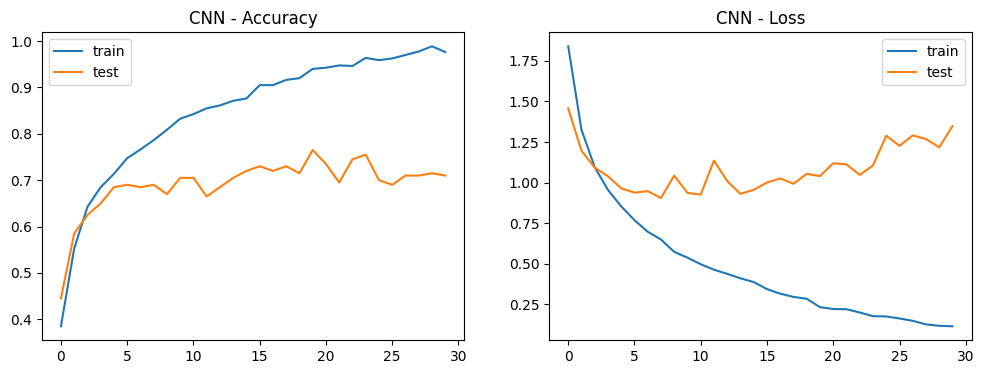

In [10]:
#CNN
cnn = models.Sequential([
    layers.Conv1D(64, 3, activation='relu', input_shape=(X_train_exp.shape[1], 1)),
    layers.MaxPooling1D(2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_cnn = cnn.fit(X_train_exp, y_train, epochs=30, validation_data=(X_test_exp, y_test), verbose=0)
print(f"CNN Result: {cnn.evaluate(X_test_exp, y_test, verbose=0)[1]:.4f}")
plot_history(h_cnn, "CNN")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RNN Result: 0.4300


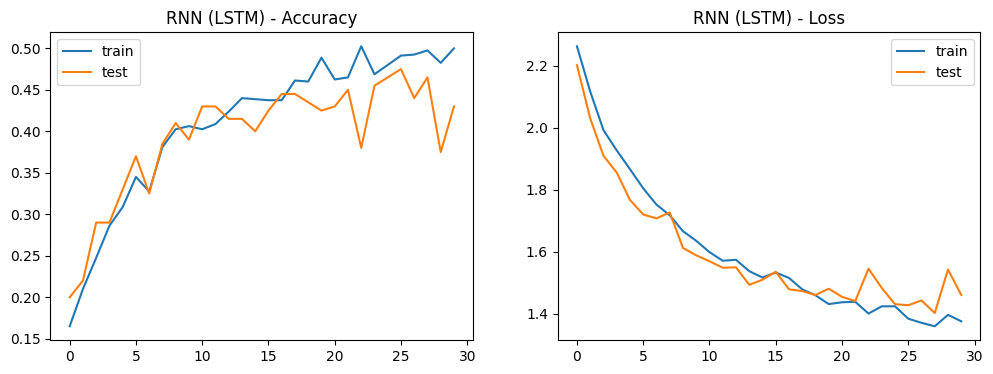

In [11]:
#RNN (LSTM)
rnn = models.Sequential([
    layers.LSTM(64, input_shape=(X_train_exp.shape[1], 1)),
    layers.Dense(10, activation='softmax')
])
rnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_rnn = rnn.fit(X_train_exp, y_train, epochs=30, validation_data=(X_test_exp, y_test), verbose=0)
print(f"RNN Result: {rnn.evaluate(X_test_exp, y_test, verbose=0)[1]:.4f}")
plot_history(h_rnn, "RNN (LSTM)")

RNN + Attention Result: 0.6100


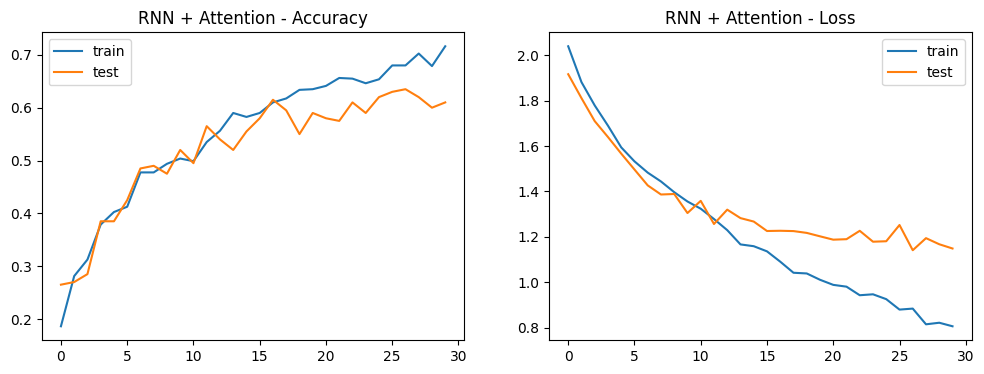

In [13]:
#RNN + Attention
def build_att_rnn():
    inputs = layers.Input(shape=(X_train_exp.shape[1], 1))
    lstm = layers.LSTM(64, return_sequences=True)(inputs)
    att = layers.Attention()([lstm, lstm])
    flat = layers.Flatten()(att)
    out = layers.Dense(10, activation='softmax')(flat)
    return models.Model(inputs, out)

att_rnn = build_att_rnn()
att_rnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_att = att_rnn.fit(X_train_exp, y_train, epochs=30, validation_data=(X_test_exp, y_test), verbose=0)
print(f"RNN + Attention Result: {att_rnn.evaluate(X_test_exp, y_test, verbose=0)[1]:.4f}")
plot_history(h_att, "RNN + Attention")

SNN/RNN Result: 0.7450


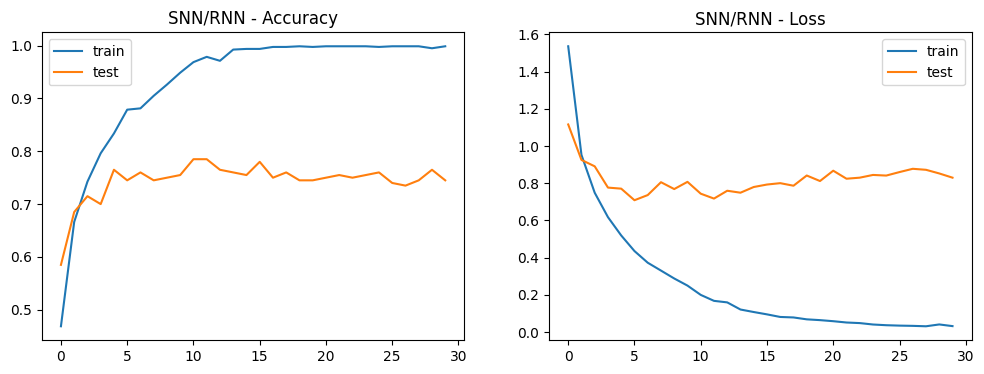

In [16]:
#SNN/RNN
hybrid = models.Sequential([
    layers.Input(shape=(X_train_exp.shape[1], 1)),
    layers.SimpleRNN(64, return_sequences=True),
    layers.Lambda(lambda x: tf.where(x > 0.3, x, tf.zeros_like(x))), # порог (передает сигнал, только если сигнал сильнее 0.3)
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])
hybrid.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_hybrid = hybrid.fit(X_train_exp, y_train, epochs=30, validation_data=(X_test_exp, y_test), verbose=0)
print(f"SNN/RNN Result: {hybrid.evaluate(X_test_exp, y_test, verbose=0)[1]:.4f}")
plot_history(h_hybrid, "SNN/RNN")

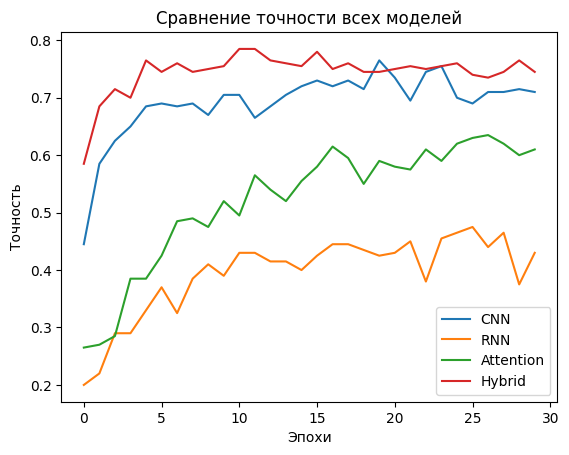

In [17]:
def plot_all():
    histories = [(h_cnn, "CNN"), (h_rnn, "RNN"), (h_att, "Attention"), (h_hybrid, "Hybrid")]
    for h, title in histories:
        plt.plot(h.history['val_accuracy'], label=title)
    plt.title('Сравнение точности всех моделей')
    plt.xlabel('Эпохи'); plt.ylabel('Точность'); plt.legend(); plt.show()

plot_all()